# EDA (Exploratory data analysis)

In [1]:
!pip install ipywidgets
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install pysentimiento --timeout=100

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install wordcloud
!pip install nltk
!pip install plotly
!pip install -U kaleido

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd
import ipywidgets as widgets
import seaborn as sns
from pysentimiento.preprocessing import preprocess_tweet

In [5]:
from wordcloud import WordCloud

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

from datasets import load_dataset

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import plot


# Helper Functions

In [6]:
# label to name
def label2name(x):
    if x == 0:
        return "Negative"
    if x == 1:
        return "Neutral"
    if x == 2:
        return "Positive"

In [7]:
import re
from typing import Union, List
import string

class CleanText():
    """ clearing text except digits () . , word character """ 

    def __init__(self, clean_pattern):
        self.clean_pattern =clean_pattern

    def __call__(self, text: Union[str, list]) -> List[List[str]]:

        if isinstance(text, str):
            docs = [[text]]

        if isinstance(text, list):
            docs = text

        text = [[re.sub(self.clean_pattern, " ", sent) for sent in sents] for sents in docs]

        return text
    
def remove_emoji(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, '', data)

def tokenize(text):
    """ basic tokenize method with word character, non word character and digits """
    text = re.sub(r" +", " ", str(text))
    text = re.split(r"(\d+|[a-zA-ZğüşıöçĞÜŞİÖÇ]+|\W)", text)
    text = list(filter(lambda x: x != '' and x != ' ', text))
    sent_tokenized = ' '.join(text)
    return sent_tokenized

regex = re.compile('[%s]' % re.escape(string.punctuation))

def remove_punct(text):
    text = regex.sub(" ", text)
    return text
# r"[^A-ZĞÜŞİÖÇIa-zğüı'şöç0-9.\"',()]"
clean = CleanText(clean_pattern=r"[^A-ZÁÉÍÓÚÜÑÇĞÜŞİÖÇIa-záéíóúüñçğüışöçĞÜŞİÖÇI'öşöç0-9.\"',()]")

In [8]:
def remove_accent(text):
    # Regex para identificar caracteres no deseados
    regex = r"[^A-ZÁÉÍÓÚÜÑÇĞÜŞİÖÇIa-záéíóúüñçğüışöçĞÜŞİÖÇI'öşöç0-9.\"',()]"
    
    # Reemplazar caracteres no deseados por una cadena vacía
    texto_limpio = re.sub(regex, ' ', text)
    texto_limpio = re.sub(r'\s+', ' ', texto_limpio)  # Reemplazar múltiples espacios por uno solo

    
    return texto_limpio

In [9]:
#keep slangs with only one word and less than 3 characters
def exclude_slangs(text):
    return len(text.split()) > 1 or len(text) <= 3
    # return False

def apply_slang_exclusion_test(df):
    # Filtrar solo las jergas y hacer una copia en una sola operación
    dfs = df.loc[df['type'] == "Jerga", ['slang', 'type']].copy()
    # Convertir las jergas a minúsculas y aplicar la función de exclusión
    dfs['exclude_slang'] = dfs['slang'].str.lower().apply(exclude_slangs)
    # Filtrar los que no deben ser excluidos
    return dfs[~dfs['exclude_slang']].drop(columns=['exclude_slang'])

def apply_slang_exclusion_1(df_slangs):
    # Filtrar solo las jergas
    df_slangs = df_slangs[df_slangs['type'] == "Jerga"]
    # Convertir las jergas a minúsculas y aplicar la función de exclusión
    df_slangs['slang'] = df_slangs['slang'].str.lower()
    df_slangs['exclude_slang'] = df_slangs['slang'].apply(exclude_slangs)
    # Filtrar los que no deben ser excluidos
    return df_slangs[~df_slangs['exclude_slang']]
    
def apply_slang_exclusion(df_slangs):
    df_slangs = df_slangs[df_slangs.type.isin(["Jerga","expresión"])]
    df_slangs['slang'] = df_slangs['slang'].apply(lambda x: x.lower())
    df_slangs['exclude_slang'] = df_slangs['slang'].apply(lambda x: exclude_slangs(x))
    dfs = df_slangs[df_slangs.exclude_slang.isin([False])]
    return dfs

# Read Data

### Raw Dataset

In [10]:
ds = load_dataset("pyupeu/social-media-peruvian-sentiment",revision='4e797116f481d2a545e52cccbc29017fbf994fcc')
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 7574
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 2367
    })
    test: Dataset({
        features: ['text', 'label', 'label_name', 'text_original', 'tokenized_text', 'sent_token_length', 'sent_bert_token_length', 'char_count', 'Character Count'],
        num_rows: 1894
    })
})

In [11]:
#convert to one pandas dataframe
df = pd.concat([ds['train'].to_pandas(), ds['validation'].to_pandas(), ds['test'].to_pandas()], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11835 entries, 0 to 11834
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   text                    11835 non-null  object
 1   label                   11835 non-null  int64 
 2   label_name              11835 non-null  object
 3   text_original           11835 non-null  object
 4   tokenized_text          11835 non-null  object
 5   sent_token_length       11835 non-null  int64 
 6   sent_bert_token_length  11835 non-null  int64 
 7   char_count              11835 non-null  int64 
 8   Character Count         11835 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 832.3+ KB


## Slangs Dictionary

In [12]:
ds_slangs = load_dataset("pyupeu/peruvian-slangs-dictionary")
ds_slangs

DatasetDict({
    train: Dataset({
        features: ['id', 'slang', 'type', 'short_description', 'description', 'source'],
        num_rows: 2344
    })
})

## Frequency of slangs in dataset

In [13]:
df_slangs = ds_slangs['train'].to_pandas()
dfs = apply_slang_exclusion(df_slangs)

In [14]:
len(dfs)

1894

In [15]:
slangs = dfs['slang'].tolist()

In [16]:
import re
from collections import Counter

def contar_jergas(text, jergas):
    words = re.findall(r'\b\w+\b', text.lower())
    jergas_en_texto = [word for word in words if word in jergas]
    return dict(Counter(jergas_en_texto))

df['jerga_frecuencia'] = df['text'].apply(lambda x: contar_jergas(x, slangs))

In [17]:
# Crear un diccionario para almacenar las frecuencias por cada etiqueta
frecuencias_por_label = {0: Counter(), 1: Counter(), 2: Counter()}

# Sumar las frecuencias de cada texto según su etiqueta
for i, row in df.iterrows():
    label = row['label']
    frecuencia = row['jerga_frecuencia']
    frecuencias_por_label[label].update(frecuencia)

# Convertir los contadores a DataFrames
df_frecuencia_negativa = pd.DataFrame(frecuencias_por_label[0].items(), columns=['slang', 'frecuencia_negativa']).sort_values(by='frecuencia_negativa', ascending=False)
df_frecuencia_neutral = pd.DataFrame(frecuencias_por_label[1].items(), columns=['slang', 'frecuencia_neutral']).sort_values(by='frecuencia_neutral', ascending=False)
df_frecuencia_positiva = pd.DataFrame(frecuencias_por_label[2].items(), columns=['slang', 'frecuencia_positiva']).sort_values(by='frecuencia_positiva', ascending=False)

# Unir los DataFrames en uno solo
df_frecuencia_total = pd.merge(df_frecuencia_positiva, df_frecuencia_negativa, on='slang', how='outer')
df_frecuencia_total = pd.merge(df_frecuencia_total, df_frecuencia_neutral, on='slang', how='outer').fillna(0)

In [18]:
len(df_frecuencia_total)

1071

In [19]:
df_frecuencia_positiva.head(30)

,slang,frecuencia_positiva
55,buenazo,93
12,arroz,75
131,chino,59
2,caldo,57
13,chicha,53
75,carajo,52
69,pollo,46
119,toque,44
115,regia,43
64,papa,40


In [20]:
top_freq1 = 40
top_freq2 = 20

## Top 40 Most used slangs

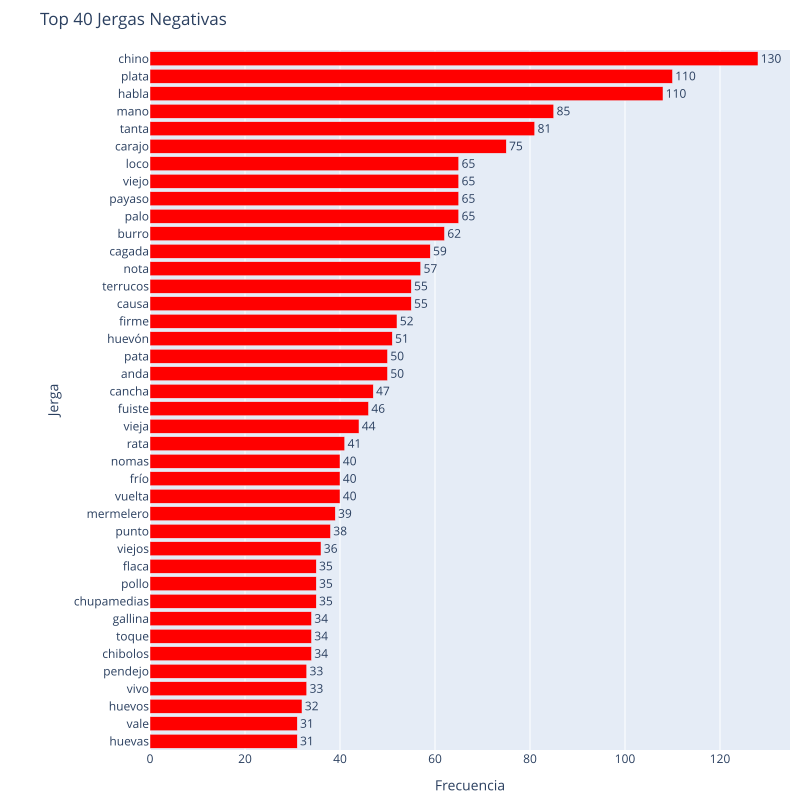

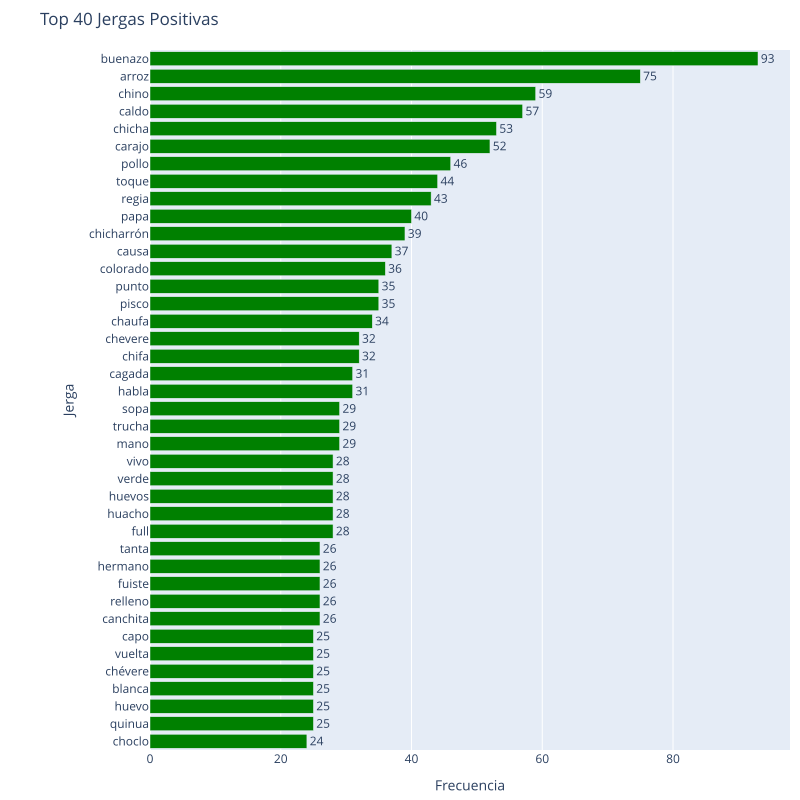

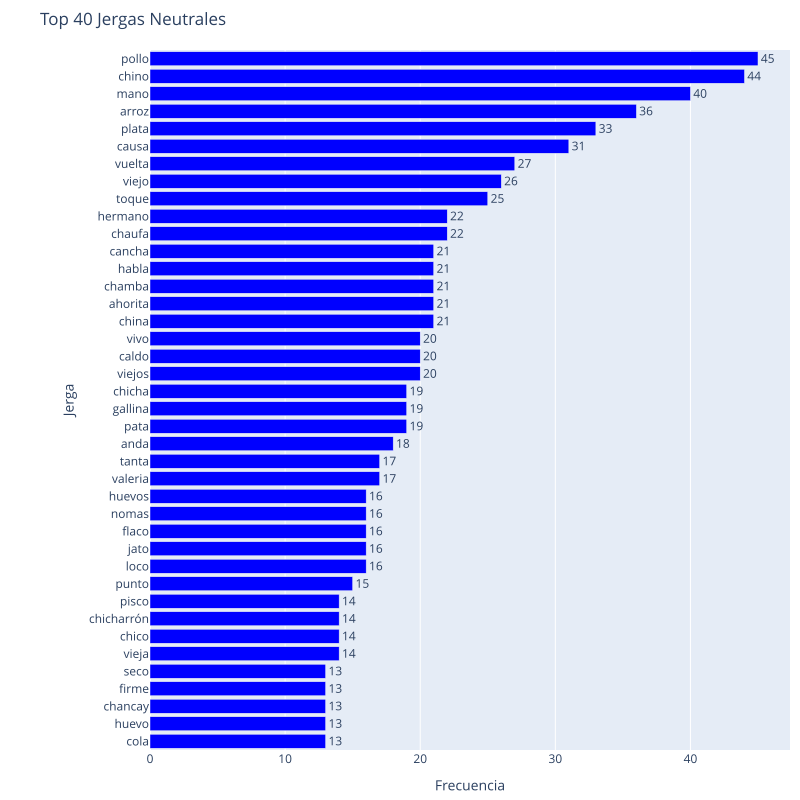

In [21]:
# Crear y mostrar gráficos individuales para cada categoría
def crear_grafico_barras_horizontal(df, column, title, color):
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=df['slang'],
        x=df[column],
        orientation='h',
        marker_color=color,
        text=df[column],  # Muestra los valores de las barras
        texttemplate='%{text:.2s}',  # Formato de los valores (dos cifras significativas)
        textposition='outside'  # Posiciona el texto fuera de las barras
    ))
    fig.update_layout(
        title=title,
        xaxis_title='Frecuencia',
        yaxis_title='Jerga',
        yaxis=dict(
            categoryorder='total ascending',  # Ordenar las barras de arriba hacia abajo
            tickangle=0
        ),
        margin=dict(l=150, r=10, t=50, b=50),  # Ajustar los márgenes para dar espacio a las etiquetas
        height=800,  # Ajustar la altura de la figura
        width=800    # Ajustar el ancho de la figura
    )
    # fig.write_html(file_name)  # Guarda el gráfico en un archivo HTML
    fig.show('svg')  # Muestra el gráfico en el navegador


#Crear gráficos para cada etiqueta
crear_grafico_barras_horizontal(df_frecuencia_negativa.head(top_freq1), 'frecuencia_negativa', 'Top ' + str(top_freq1) + ' Jergas Negativas', 'red')
crear_grafico_barras_horizontal(df_frecuencia_positiva.head(top_freq1), 'frecuencia_positiva', 'Top ' + str(top_freq1) + ' Jergas Positivas', 'green')
crear_grafico_barras_horizontal(df_frecuencia_neutral.head(top_freq1), 'frecuencia_neutral', 'Top ' + str(top_freq1) + ' Jergas Neutrales', 'blue')


## Top 30 most used slangs

In [40]:
df_frecuencia_negativa

,slang,frecuencia_negativa
0,chino,128
151,plata,110
102,habla,108
101,mano,85
5,tanta,81
...,...,...
683,grifo,1
684,maní,1
685,sorete,1
686,huasca,1


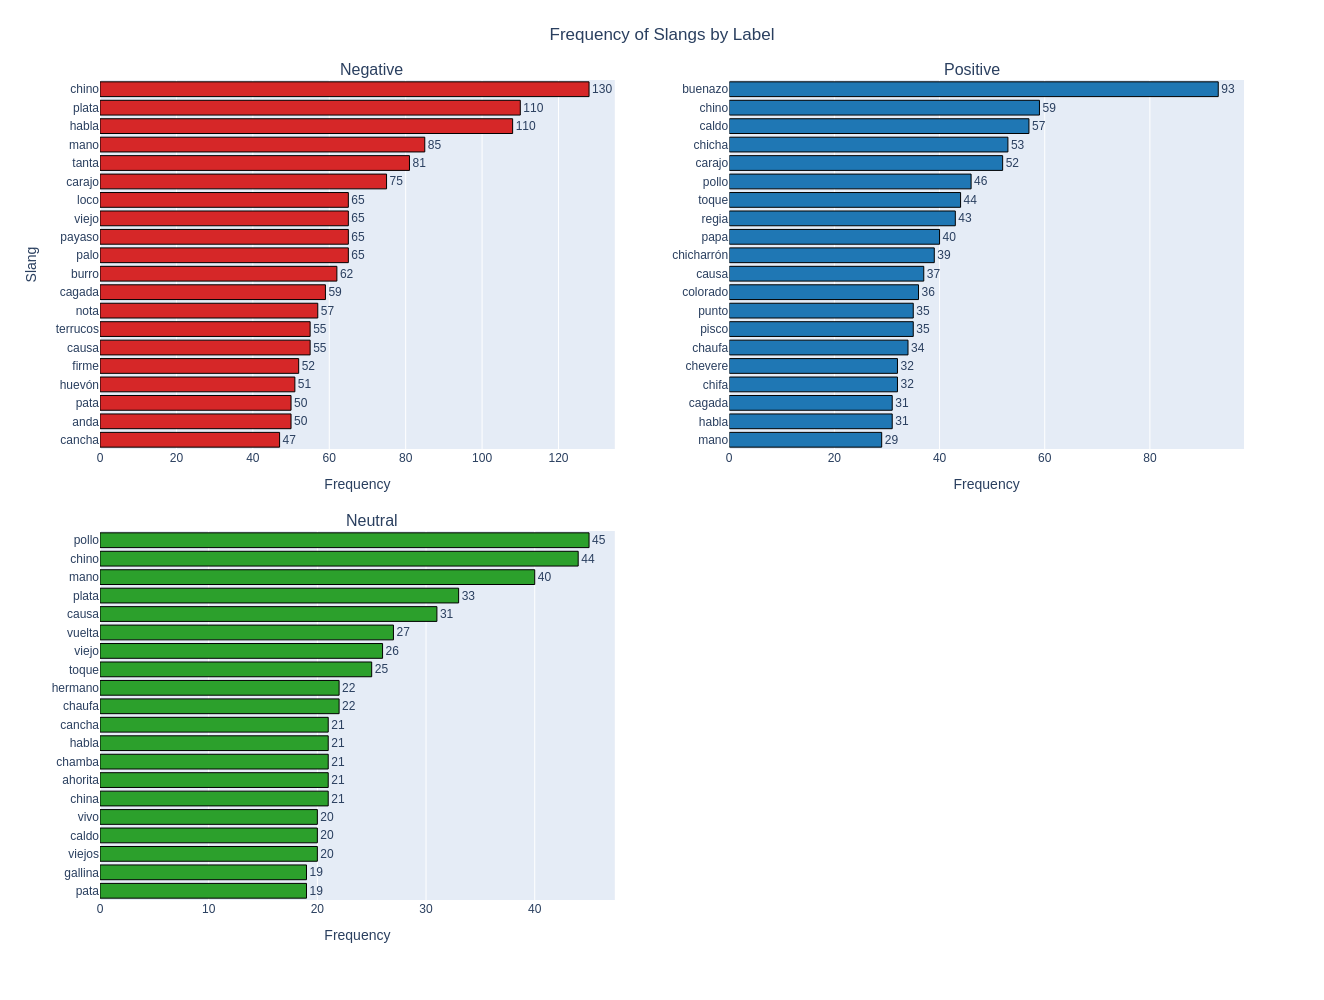

In [41]:
# Crear un subplot con 3 gráficos horizontales en columnas
fig = make_subplots(rows=2, cols=2, shared_yaxes=False, 
                    subplot_titles=('Negative', 'Positive', 'Neutral'),
                    horizontal_spacing=0.05,
                   vertical_spacing=0.1)  # Ajustar el espaciado horizontal

# Función para agregar gráficos a los subplots
def agregar_grafico_a_subplot(fig, df, column, row, col, color):
    fig.add_trace(go.Bar(
        x=df[column],
        y=df['slang'],
        orientation='h',
        marker_color=color,
        text=df[column],
        texttemplate='%{text:.2s}',
        textposition='outside',
        marker_line=dict(color='black', width=1)
    ), row=row, col=col)

# Agregar cada gráfico a un subplot
agregar_grafico_a_subplot(fig, df_frecuencia_negativa.head(top_freq2), 'frecuencia_negativa', row=1, col=1, color='#d62728')
agregar_grafico_a_subplot(fig, df_frecuencia_positiva.head(top_freq2), 'frecuencia_positiva', row=1, col=2, color='#1f77b4')
agregar_grafico_a_subplot(fig, df_frecuencia_neutral.head(top_freq2), 'frecuencia_neutral', row=2, col=1, color='#2ca02c')

# Actualizar el diseño de la figura
fig.update_layout(
    title_text='Frequency of Slangs by Label',
    title_x=0.5,  # Centrar el título
    xaxis_title='Frequency',
    yaxis_title='Slang',
    height=1000,  # Ajustar la altura de la figura
    width=1324,  # Ajustar el ancho de la figura para acomodar los gráficos
    margin=dict(l=100, r=80, t=80, b=100),  # Ajustar los márgenes
    showlegend=False,

)
# Ajustar el ancho relativo de cada subplot usando domain
fig.update_xaxes(domain=[0, 0.45], row=1, col=1)  # Primer gráfico
fig.update_xaxes(domain=[0.55, 1], row=1, col=2)  # Segundo gráfico
fig.update_xaxes(domain=[0, 0.45], row=2, col=1)  # Tercer gráfico
fig.update_xaxes(
    title_text='Frequency',  # Añadir título al eje x
    title_font=dict(size=14),  # Tamaño de la fuente del título
    tickfont=dict(size=12)  # Tamaño de la fuente de los ticks
)

# Actualizar los ejes y el formato de las etiquetas
fig.update_yaxes(
    categoryorder='total ascending',  # Ordenar las barras de arriba hacia abajo
    tickangle=0,  # Mantener los ticks del eje vertical horizontales
    title_font=dict(size=14),  # Tamaño de la fuente del título

    # row=2, col=1
)
# fig.update_yaxes(
#     categoryorder='total ascending',  # Ordenar las barras de arriba hacia abajo
#     tickangle=0,  # Mantener los ticks del eje vertical horizontales
#     row=1, col=2
# )
# fig.update_yaxes(
#     categoryorder='total ascending',  # Ordenar las barras de arriba hacia abajo
#     tickangle=0,  # Mantener los ticks del eje vertical horizontales
#     # row=1, col=3
# )

# Mostrar el gráfico
fig.show('png')
fig.write_image("images/frequencies.png")

In [23]:
# encode label and mapping label name
#df["label"] = df["label"].apply(lambda x: label_encode(x))
df["label_name"] = df["label"].apply(lambda x: label2name(x))

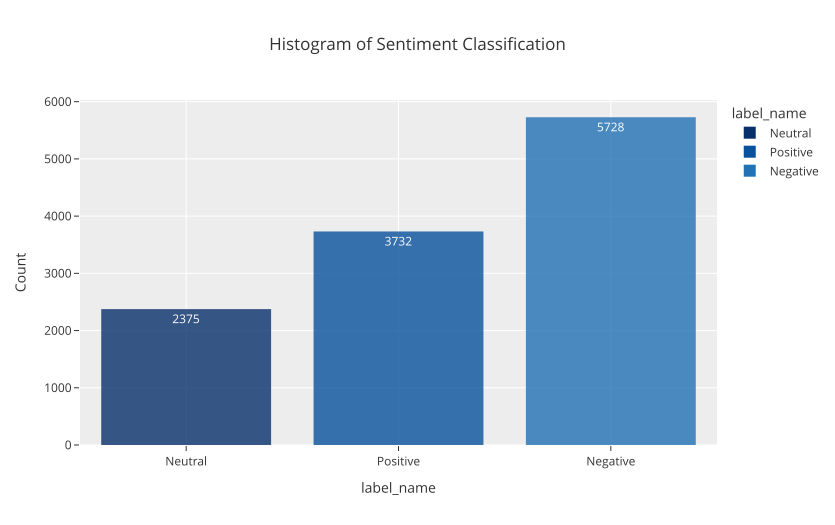

In [24]:
# count of ratings
fig = px.histogram(df,
             x = 'label_name',
             title = 'Histogram of Sentiment Classification',
             template = 'ggplot2',
             color = 'label_name',
             color_discrete_sequence= px.colors.sequential.Blues_r,
             category_orders=dict(label_name=["Neutral", "Positive", "Negative"]),
             text_auto=True,
             opacity = 0.8,
             height = 525,
             width = 835,
            )

fig.update_yaxes(title='Count')
# fig.show()
fig.show('svg')

In [25]:
# clean text, lowercase and remove punk
# df["text"] = df["text"].apply(lambda x: preprocess_tweet(x))
df["text_original"] = df["text"]
#df["text"] = df["text"].apply(lambda x: remove_punct(clean(remove_emoji(x).lower())[0][0]))
df["text"] = df["text"].apply(lambda x: preprocess_tweet(x.lower(), demoji=False))

In [26]:
df.head()

,text,label,label_name,text_original,tokenized_text,sent_token_length,sent_bert_token_length,char_count,Character Count,jerga_frecuencia
0,renzo crispin javier güere baluarte se pasaron...,0,Negative,renzo crispin javier güere baluarte se pasaron...,renzo crispin javier güere baluarte se pasaron...,10,15,58,58,{}
1,chino risas pa que llevas a tus maleteros 🤡🤡🤡,0,Negative,chino risas pa que llevas a tus maleteros 🤡🤡🤡,chino risas pa que llevas a tus maleteros 🤡🤡🤡,9,10,45,45,{'chino': 1}
2,estudia p chato 😵‍💫🙈,0,Negative,estudia p chato 😵‍💫🙈,estudia p chato 😵‍💫🙈,4,4,20,20,{'chato': 1}
3,"no seas pendejo, jaja tatuaje borra entonces... 😂",0,Negative,"no seas pendejo, jaja tatuaje borra entonces... 😂",no seas pendejo jaja tatuaje borra entonces 😂,8,9,49,49,{'pendejo': 1}
4,todas las autoridades y las actuales son culpa...,0,Negative,todas las autoridades y las actuales son culpa...,todas las autoridades y las actuales son culpa...,21,23,121,121,{'tira': 1}


In [27]:
df.sample(n = 30)

,text,label,label_name,text_original,tokenized_text,sent_token_length,sent_bert_token_length,char_count,Character Count,jerga_frecuencia
1664,q ascooo carajo x mas comico q sea deben tener...,0,Negative,q ascooo carajo x mas comico q sea deben tener...,q ascooo carajo x mas comico q sea deben tener...,22,25,107,107,"{'carajo': 2, 'chino': 1}"
10470,mireeennn!!! vaooo!!! trilce micaela zeila lib...,2,Positive,mireeennn!!! vaooo!!! trilce micaela zeila lib...,mireeennn vaooo trilce micaela zeila lib...,26,41,162,162,{'micaela': 1}
7877,"eddy ronald me quedo jato a las 12, no llego n...",0,Negative,"eddy ronald me quedo jato a las 12, no llego n...",eddy ronald me quedo jato a las 12 no llego n...,18,22,80,80,{'jato': 1}
7784,ya no sabes q hacer beto fujimori prepárate el...,2,Positive,ya no sabes q hacer beto fujimori prepárate el...,ya no sabes q hacer beto fujimori prepárate el...,21,22,115,115,{'rondero': 1}
10147,jaja yerri navarro quesquen hermano las que te...,1,Neutral,jaja yerri navarro quesquen hermano las que te...,jaja yerri navarro quesquen hermano las que te...,13,15,76,76,"{'hermano': 1, 'flaco': 1}"
6641,"grande tobi, aunque fueses fujimorista igual m...",2,Positive,"grande tobi, aunque fueses fujimorista igual m...",grande tobi aunque fueses fujimorista igual m...,53,63,288,288,"{'paja': 1, 'roche': 1, 'palta': 1, 'viejo': 1}"
11225,¿de verdad quieren mechar?,0,Negative,¿de verdad quieren mechar?,¿de verdad quieren mechar,4,6,26,26,{'mechar': 1}
8898,eres verdad son unos vagos les duele su verdad...,0,Negative,eres verdad son unos vagos les duele su verdad...,eres verdad son unos vagos les duele su verdad...,10,10,52,52,{}
3636,aunque ud no lo crea pero es real este ministr...,0,Negative,aunque ud no lo crea pero es real este ministr...,aunque ud no lo crea pero es real este ministr...,102,125,559,559,"{'monigote': 1, 'medias': 1, 'plata': 1, 'canc..."
3502,yo si lobaile 👍👍👍😝😝😝,2,Positive,yo si lobaile 👍👍👍😝😝😝,yo si lobaile 👍👍👍😝😝😝,4,6,20,20,{}


# Visualizations

## Word Cloud of dataset

In [28]:
nltk.download("stopwords")
stopwords = set(stopwords.words('spanish'))
stopwords.update([ "x", "xq","q","k","Jajajaa","perra","kieren","verga","jaja", "jjaja"])

def show_wordcloud(data, title=None, save=False, filename="wordcloud.png"):
    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=200,
        max_font_size=40, 
        scale=3,  # Aumentar el valor de scale para mejorar la resolución
        random_state=1
    ).generate(" ".join(data))

    fig = plt.figure(1, figsize=(20, 20))  # Aumentar figsize para mayor tamaño
    plt.axis('off')
    if title: 
        fig.suptitle(title, fontsize=24, weight='bold')
        fig.subplots_adjust(top=2.3)

    plt.imshow(wordcloud, interpolation='bilinear')

    if save:
        plt.savefig(filename, dpi=300, bbox_inches='tight')  # Guardar la imagen en alta resolución

    plt.show()


[nltk_data] Downloading package stopwords to /home/jair/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
show_wordcloud(df["text"].values)

ValueError: Only supported for TrueType fonts

# Target Count

In [ ]:
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "bar"}]])
colors = ['#191970', '#8B008B', 'darkorange'] # darkorange
fig.add_trace(go.Pie(labels=df.label_name.value_counts().index,
                             values=df.label.value_counts().values), 1, 1)

fig.update_traces(hoverinfo='label+percent', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=2)))

fig.add_trace(go.Bar(x=df.label_name.value_counts().index, y=df.label.value_counts().values, marker_color = colors), 1,2)

fig.show('svg')
# fig.show()

# Token Counts with simple tokenizer¶

In [ ]:
# tokenize data
#df["tokenized_text"] = df.text.apply(lambda x: tokenize(x))
df["tokenized_text"] = df.text.apply(lambda x: preprocess_tweet(x, demoji=False))
# calculate token count for any sent
df["sent_token_length"] = df["tokenized_text"].apply(lambda x: len(x.split()))

In [ ]:
fig = px.histogram(df, x="sent_token_length", nbins=20, barmode='group', histnorm="percent")
# fig.show()
fig.show('svg')

In [ ]:
(df.sent_token_length < 200).mean()

In [ ]:
#Token Counts with roBERTuito tokenizer

In [ ]:
from transformers import AutoTokenizer
model_name = "pysentimiento/robertuito-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# data tokenize with bert tokenizer
df["sent_bert_token_length"] = df["text"].apply(lambda x: len(tokenizer(x, add_special_tokens=False)["input_ids"]))

In [ ]:
fig = px.histogram(df, x="sent_bert_token_length", nbins=20, barmode='group', histnorm="percent")
# fig.show()
fig.show('svg')

In [ ]:
# Less than 512 covers how many of the data
(df.sent_bert_token_length < 200).mean()

In [ ]:
#Characters Count in the Data

In [ ]:

# valvulate char count for each review
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

def plot_dist3(df, feature, title):
    fig = plt.figure(constrained_layout=True, figsize=(18, 8))
    grid = gridspec.GridSpec(ncols=3, nrows=3, figure=fig)
    ax1 = fig.add_subplot(grid[0, :2])
    ax1.set_title('Histogram')
    sns.histplot(df.loc[:, feature],
                 # kde=True,
                 ax=ax1,
                  binrange=(0, 800)
                 )
    ax1.set(ylabel='Frequency')
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=20))


    plt.suptitle(f'{title}', fontsize=24)

In [ ]:
plot_dist3(df, 'char_count',
           'Characters Count in Data')

# Reviews Lengths

In [ ]:
# Creating a new feature for the visualization.
df['Character Count'] = df['text'].apply(lambda x: len(str(x)))


def plot_dist3(df, feature, title, xlim=(0, 800)):
    """Plot histogram and ECDF with a style suitable for a paper and controlled x-axis limit."""
    
    sns.set(style="whitegrid", palette="muted", font_scale=1.5)
    
    # Configuración de la figura
    fig = plt.figure(constrained_layout=True, figsize=(16, 10))
    grid = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, width_ratios=[2, 1], height_ratios=[1, 1])
    
    # Histograma
    ax1 = fig.add_subplot(grid[0, 0])
    sns.histplot(df[feature], kde=True, ax=ax1, color="skyblue", edgecolor="black")
    ax1.set_title('Histogram', fontsize=18, weight='bold')
    ax1.set_xlabel('Character Count', fontsize=14)
    ax1.set_ylabel('Density', fontsize=14)
    ax1.xaxis.set_major_locator(MaxNLocator(nbins=20))
    if xlim:
        ax1.set_xlim(xlim)

    # ECDF
    ax2 = fig.add_subplot(grid[1, 0])
    sns.histplot(df[feature], ax=ax2, kde=True, kde_kws={'cumulative': True}, color="salmon", edgecolor="black")
    ax2.set_title('Empirical CDF', fontsize=18, weight='bold')
    ax2.set_xlabel('Character Count', fontsize=14)
    ax2.set_ylabel('Cumulative Probability', fontsize=14)
    ax2.xaxis.set_major_locator(MaxNLocator(nbins=20))
    if xlim:
        ax2.set_xlim(xlim)

    # Ajuste del layout y título principal
    fig.suptitle(f'{title}', fontsize=24, weight='bold', y=1.02)
    # fig.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Mostrar el gráfico
    plt.show()

In [ ]:
plot_dist3(df[df['label'] == 0], 'Character Count',
           'Characters Count "Negative" Text')

In [ ]:
plot_dist3(df[df['label'] == 2], 'Character Count',
           'Characters Per "Positive" Text')

In [ ]:
plot_dist3(df[df['label'] == 1], 'Character Count',
           'Characters Per "Neutral" Text')

# Word Counts

In [ ]:
def plot_word_number_histogram(textno, textye, textz, xlim=None):
    """A function for comparing word counts with a style suitable for a paper and controlled x-axis limit"""
    
    sns.set(style="whitegrid", palette="muted", font_scale=1.5)

    fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(10, 15), sharey=True)
    
    # Histograma para textos negativos
    sns.histplot(textno.str.split().map(lambda x: len(x)), ax=axes[0], kde=True, stat="density", kde_kws=dict(cut=3), color="skyblue", edgecolor="black")
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Negative', fontsize=18, weight='bold')
    if xlim:
        axes[0].set_xlim(xlim)
    
    # Histograma para textos neutrales
    sns.histplot(textye.str.split().map(lambda x: len(x)), ax=axes[1], kde=True, stat="density", kde_kws=dict(cut=3), color="lightgreen", edgecolor="black")
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Neutral', fontsize=18, weight='bold')
    if xlim:
        axes[1].set_xlim(xlim)

    # Histograma para textos positivos
    sns.histplot(textz.str.split().map(lambda x: len(x)), ax=axes[2], kde=True, stat="density", kde_kws=dict(cut=3), color="salmon", edgecolor="black")
    axes[2].set_xlabel('Word Count', fontsize=14)
    axes[2].set_ylabel('Density')
    axes[2].set_title('Positive', fontsize=18, weight='bold')
    if xlim:
        axes[2].set_xlim(xlim)

    # Título principal
    fig.suptitle('Words Per Review', fontsize=24, weight='bold')
    
    # Ajuste de layout
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    # Mostrar el gráfico
    plt.show()

In [ ]:
plot_word_number_histogram(df[df['label'] == 0]['text'],
                           df[df['label'] == 1]['text'],
                           df[df['label'] == 2]['text'],xlim=(0, 100)
                          )

In [ ]:
# remove punctuation 
df['tokenized_text'] = df['tokenized_text'].apply(lambda x: remove_punct(x))

In [ ]:
df['tokenized_text'].sample(20)

In [ ]:
pd.set_option("max_colwidth", 200)

In [ ]:
# df['tokenized_text']
df["tokenized_text"] = df["tokenized_text"].apply(lambda x: remove_emoji(x).lower())

In [ ]:
texts = df['tokenized_text']
new = texts.str.split()
new = new.values.tolist()

# Most Common Words

In [ ]:
from collections import Counter, defaultdict

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopWords_nltk = set(stopwords.words('spanish'))
stopWords_nltk.update([ "x", "xq","q","k","Jajajaa","perra","kieren","verga","jaja", 'si', 'Y', 'hace', 'mas', 'ver','ser','va','tan'])

texts = df['tokenized_text']
new = texts.str.split()
new = new.values.tolist()
corpus = [word for i in new for word in i]
counter = Counter(corpus)
most = counter.most_common()
x, y = [], []
for word, count in most[:100]:
    if word not in stopWords_nltk:
        x.append(word)
        y.append(count)

fig = go.Figure(go.Bar(
            x=y,
            y=x,
            orientation='h',  marker=dict(
        color='rgba(50, 171, 96, 0.6)',
        line=dict(
            color='rgba(50, 171, 96, 1.0)',
            width=1),
    ),
    name='Most common Word',))

fig.update_layout( title={
        'text': "Most Common Words",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'},
        font=dict(
            family="Courier New, monospace",
            size=18,
            color="RebeccaPurple"),
        height=800,
        width=1024 )

# fig.show()
fig.show("png")

## Most Common ngrams

In [ ]:
fig = make_subplots(rows=1, cols=3)
title_ = ["negative", "neutral", "positive"]

for i in range(3):
    texts = df[df["label"] == i]['tokenized_text']

    new = texts.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]
    counter = Counter(corpus)
    most = counter.most_common()
    x, y = [], []

    for word, count in most[:100]:
        if word not in stopWords_nltk:
            x.append(word)
            y.append(count)

    fig.add_trace(go.Bar(
                x=y,
                y=x,
                orientation='h', type="bar",
        name=title_[i], marker=dict(color=colors[i])), 1, i+1)
    
fig.update_layout(
    autosize=False,
    width=2000,
    height=800,title=dict(
        text='<b>Most Common ngrams per Classes</b>',
        x=0.5,
        y=0.95,
        font=dict(
            family="Courier New, monospace",
            size=24,
            color="RebeccaPurple"
        )
    ),)


# fig.show()
fig.show("svg")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
def _get_top_ngram(corpus, n=None):
    #getting top ngrams
    vec = CountVectorizer(ngram_range=(n, n),
                          max_df=0.9,
                          ).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:15]

In [ ]:
# unigram
fig = make_subplots(rows=1, cols=3)

title_ = ["negative", "neutral", "positive"]

for i in range(3):
    texts = df[df["label"] == i]['tokenized_text']

    new = texts.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]
    top_n_bigrams = _get_top_ngram(texts, 2)[:15]
    x, y = map(list, zip(*top_n_bigrams))


    fig.add_trace(go.Bar(
                x=y,
                y=x,
                orientation='h', type="bar",
        name=title_[i], marker=dict(color=colors[i])), 1, i+1)
    

fig.update_layout(
    autosize=False,
    width=2000,
    height=600,title=dict(
        text='<b>Most Common unigrams per Classes</b>',
        x=0.5,
        y=0.95,
        font=dict(
        family="Courier New, monospace",
        size=24,
        color="RebeccaPurple"
        )
    ))      
# fig.show()
fig.show("png")

In [ ]:
#trigram

fig = make_subplots(rows=1, cols=3)
title_ = ["negative", "neutral", "positive"]

for i in range(3):
    texts = df[df["label"] == i]['tokenized_text']

    new = texts.str.split()
    new = new.values.tolist()
    corpus = [word for i in new for word in i]

    top_n_bigrams = _get_top_ngram(texts, 3)[:15]
    x, y = map(list, zip(*top_n_bigrams))

    fig.add_trace(go.Bar(
                x=y,
                y=x,
                orientation='h', type="bar",
        name=title_[i], marker=dict(color=colors[i])), 1, i+1),

fig.update_layout(
    autosize=False,
    width=2000,
    height=600,title=dict(
        text='<b>Most Common trigrams per Classes</b>',
        x=0.5,
        y=0.95,
        font=dict(
        family="Courier New, monospace",
        size=24,
        color="RebeccaPurple"
        )
    ))
    
# fig.show()
fig.show("png")

In [ ]:
df['text'].sample(20)